# Linear Sequential Estimation

In [36]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(1)

In [37]:
# Import functions directly from github
# Important: note that we use raw.githubusercontent.com, not github.com

import requests
url = 'https://raw.githubusercontent.com/florisvb/Nonlinear_and_Data_Driven_Estimation/main/Utility/plot_utility.py'
r = requests.get(url)

# Store the file to the colab working directory
with open('plot_utility.py', 'w') as f:
    f.write(r.text)

# import the function we want from that file
from plot_utility import plot_tme

# Generate sample time series data

In [38]:
t = np.linspace(0, 6, 500)
x = np.array([[1, 1, 2, -0.4e-4]]).T
H = np.vstack([t, np.sin(t), np.cos(2*t), np.exp(t)]).T
y = H@x

# Add some normal (gaussian) noise

In [39]:
# Example for Gaussian (normal) random variable

noise_mean = 0
noise_std = 0.5

v = np.column_stack(np.random.normal(noise_mean, noise_std, len(y))).T

In [40]:
y_tilde = y+v

# Plotting

<Axes: xlabel='Time', ylabel='y'>

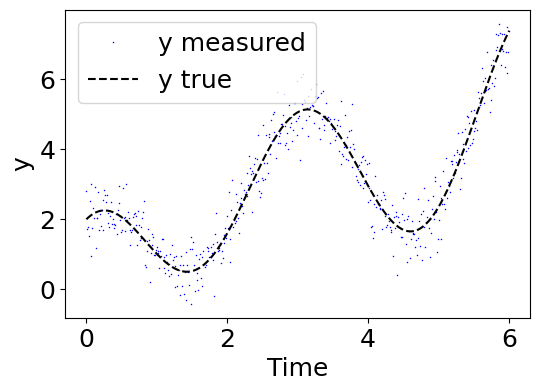

In [41]:
plot_tme(t, y, y_tilde)

# Candidate models

In [42]:
model_1_H = np.vstack([t, np.sin(t), np.cos(2*t)]).T

# Exercise

Implement Linear Sequential Estimation, and plot the three parameters of $x$ over time

In [43]:
import numpy as np

In [44]:
# x_2_hat = x_1_hat + P_2 * H_2.T * W_2 [y_2_tilde - H_2 * x_1_hat]
# 3x1 = 3x1 + 3x3 * 3x1 * 1x1 [1x1 - 1x3 * 3x1]

In [45]:
x0 = np.array([[0, 0, 0]]).T
x0=[x0] # start out w/initial guess

P0 = 10 * np.eye(3)

In [46]:
def update(x_k, P_k, H_kp1, y_kp1, W):
  # x_k: previous state estimate, we are estimating x_(k+1)
  inv_P_k = np.linalg.inv(P_k)
  inv_P_kp1 = inv_P_k + H_kp1.T@W@H_kp1
  P_kp1 = np.linalg.inv(inv_P_kp1)
  x_kp1 = x_k + P_kp1@H_kp1.T@W@(y_kp1 - H_kp1@x_k)
  return x_kp1, P_kp1

In [47]:
model_1_H.shape

(500, 3)

In [48]:
model_1_H[5,:].shape
np.atleast_2d(model_1_H[5,:]).shape

(1, 3)

In [57]:
x_hats = [x0]
Ps = [P0]

for i in range(y_tilde.shape[0]):
  x_k = x_hats[-1]
  P_k = Ps[-1]
  H_kp1 = np.atleast_2d(model_1_H[i,:])
  y_kp1 = np.atleast_2d(y_tilde[i,:])
  W = np.array([[1]]) # identify matrix
  x_kp1, P_kp1 = update(x_k, P_k, H_kp1, y_kp1, W)
  x_hats.append(x_kp1)
  Ps.append(P_kp1)

In [58]:
X = np.hstack(x_hats)
X

array([[[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [1.00798051],
        [1.04553443],
        [1.9883833 ]]])

IndexError: index 1 is out of bounds for axis 0 with size 1

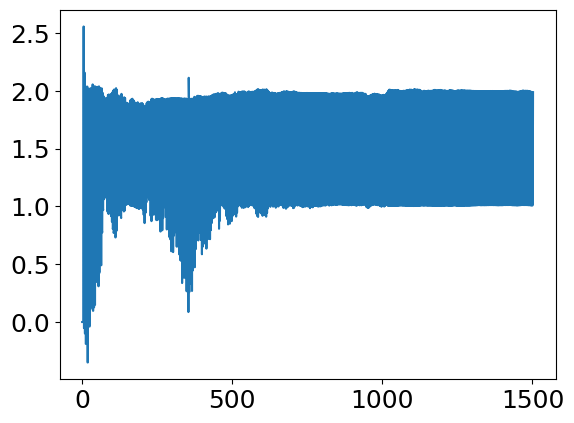

In [59]:
plt.plot(X[0,:])
plt.plot(X[1,:])
plt.plot(X[2,:])